# Grids and States

Welcome to the first SAETASS tutorial! In this notebook, we will explore the fundamental building blocks of any SAETASS simulation: the **Grid** and the **State**.

## 1. What is a Grid?

In SAETASS, a `Grid` object defines the discrete coordinates where our physical values live. Since SAETASS is designed for astrophysical transport (like cosmic rays), it handles two main types of coordinates:
- **Spatial (r)**: Usually representing radial distance in a spherical system.
- **Momentum (p)**: Representing the particle energy or momentum.

Let's start by importing the necessary modules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from saetass.grid import Grid
from saetass.state import State

### Creating a basic Grid

The easiest way to create a grid is using the `Grid.uniform` factory method. This creates a linearly spaced grid in the specified ranges.

In [2]:
# Create a uniform spatial grid from 0 to 10 pc with 100 cells
grid = Grid.uniform(
    r_min=0.0, 
    r_max=10.0, 
    num_r_cells=100
)

print(grid)

Grid:
  Spatial range: -0.050505050505050504 to 10.05050505050505
  Number of spatial cells: 100


### Scientific Grids: Logarithmic Spacing

In astrophysics, momentum/energy spectra often span many orders of magnitude. For these cases, a `log_spaced` grid is much more appropriate.

In [3]:
# Create a log-spaced momentum grid from 1 GeV to 100 TeV
p_grid = Grid.log_spaced(
    p_min=1.0, 
    p_max=1e5, 
    num_p_cells=40
)

print(p_grid)

Grid:
  Momentum range: -0.0818121636751463 to 5.052235883029611
  Number of momentum cells: 40


## 2. What is a State?

A `State` is the object that actually carries the physics. It contains the distribution function $f(p, r, t)$ and keeps track of the simulation time and metadata.

Let's create a `State` for our spatial grid with an initial Gaussian distribution.

In [4]:
# Define an initial profile: a Gaussian centered at r=5
r = grid.r_centers
f_initial = np.exp(-(r - 5.0)**2 / (2 * 0.5**2))

# Instantiate the State object
state = State(f=f_initial, t=0.0)

print(state)

State(t=0.000, dt=0.000, stage=0, stage_name='', f_shape=(1, 100), history_len=0)


## 3. Visualizing the Initial Condition

One of the best ways to understand your setup is to plot it. Since `State` wraps the distribution array, we use `state.get_f()` to access the raw values for plotting.

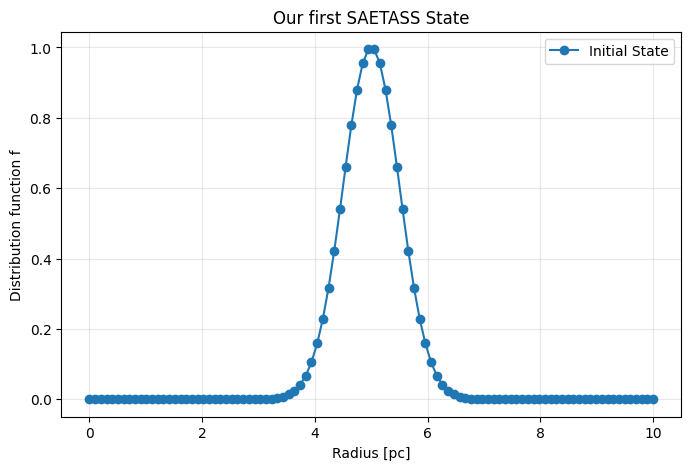

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(grid.r_centers, state.get_f(), 'o-', label='Initial State')
plt.xlabel('Radius [pc]')
plt.ylabel('Distribution function f')
plt.title('Our first SAETASS State')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Summary

In this tutorial, you learned:
1. How to create **uniform** and **log-spaced** grids.
2. How to initialize a **State** with a physical distribution.
3. How to access the data for **visualization**.

In the next tutorial, we will see how to put this state inside a **Solver** to see how it evolves over time!